In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# =========================
# PREREQUISITOS DEL NOTEBOOK
# =========================

import os
import pandas as pd
import numpy as np
import kagglehub

# 1. Descargar/cargar el dataset de la competencia
path = kagglehub.competition_download(
    "rsna-knee-abnormality-detection"
)

print("Dataset:", path)

# 2. Cargar train.csv
train = pd.read_csv(
    os.path.join(path, "train.csv")
)

# 3. Definir las 12 etiquetas
LABELS = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
]

# 4. Quedarnos solo con estudios que tienen las 12 etiquetas completas
gold = train.dropna(subset=LABELS).copy()

# 5. Contar cuántas anomalías positivas tiene cada estudio
gold["cantidad_anomalias"] = gold[LABELS].sum(axis=1)

# 6. Quedarnos solo con los estudios que tienen exactamente 1 anomalía
una_anomalia = gold[
    gold["cantidad_anomalias"] == 1
].copy()

# 7. Identificar cuál es esa única anomalía
una_anomalia["anomalia"] = (
    una_anomalia[LABELS]
    .idxmax(axis=1)
)

# 8. Verificación
print("Estudios con las 12 etiquetas completas:", len(gold))
print("Estudios con exactamente 1 anomalía:", len(una_anomalia))

display(
    una_anomalia[
        ["StudyInstanceUID", "anomalia", "cantidad_anomalias"]
    ]
)

Dataset: /kaggle/input/competitions/rsna-knee-abnormality-detection
Estudios con las 12 etiquetas completas: 58
Estudios con exactamente 1 anomalía: 8


,StudyInstanceUID,anomalia,cantidad_anomalias
445,1.2.826.0.1.3680043.8.498.11287937729196958426...,Effusion,1.0
1027,1.2.826.0.1.3680043.8.498.12978510157202852202...,Fracture,1.0
1707,1.2.826.0.1.3680043.8.498.27437263843446879932...,Medial Meniscus,1.0
2480,1.2.826.0.1.3680043.8.498.48348615349418615469...,MCL,1.0
2727,1.2.826.0.1.3680043.8.498.54977581323931277817...,Lateral Meniscus,1.0
3240,1.2.826.0.1.3680043.8.498.69392348385274125385...,PF OA,1.0
3376,1.2.826.0.1.3680043.8.498.72853333220043794904...,MCL,1.0
4187,1.2.826.0.1.3680043.8.498.94433753471890306108...,Baker's,1.0


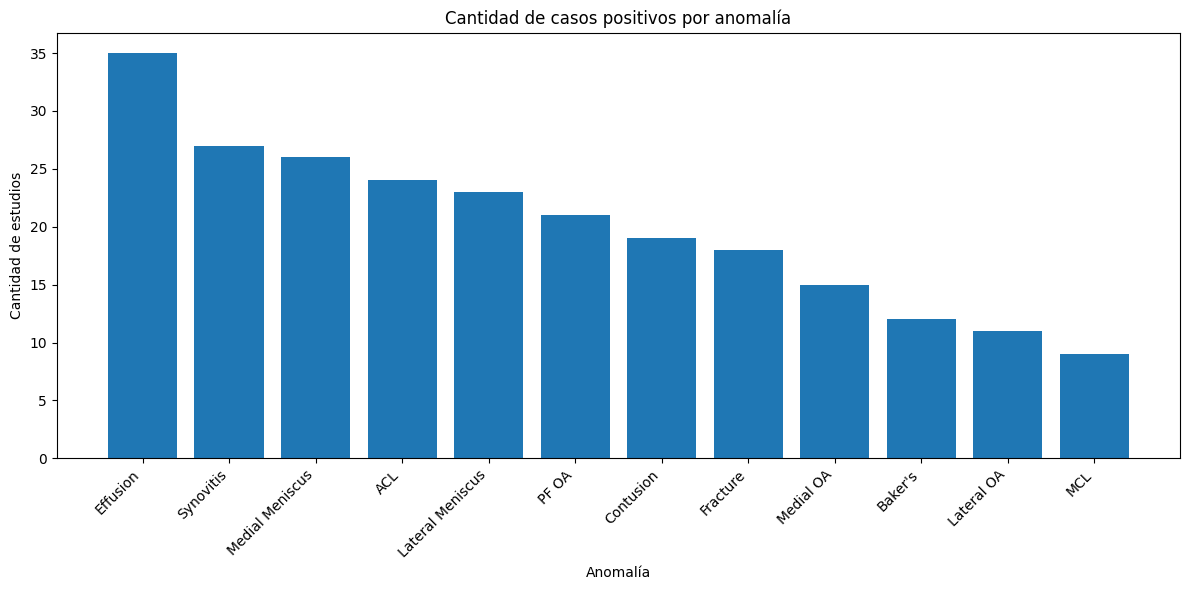

In [2]:
import matplotlib.pyplot as plt

# Contar cuántos estudios positivos hay para cada anomalía
conteo_anomalias = gold[LABELS].sum().sort_values(ascending=False)

# Crear gráfico
plt.figure(figsize=(12, 6))

plt.bar(
    conteo_anomalias.index,
    conteo_anomalias.values
)

plt.title("Cantidad de casos positivos por anomalía")
plt.xlabel("Anomalía")
plt.ylabel("Cantidad de estudios")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()